In [3]:
# Cell 4: Define functions for Perlin noise generation and region expansion
import os
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from skimage.measure import label as cc_label
from skimage.measure import regionprops
from skimage.segmentation import active_contour
from noise import pnoise2
import random

from dataset import MaskOnlyDataset,label_to_rgb, translate_1d_to_rgb,extract_connected_regions
from dataset import MaskOnlyDataset, random_translate_region, random_translate_and_rotate_region,random_translate_and_rotate_regionv2


from transformations import generate_perlin_noise_2d,perlin_expand_region,active_contour_expand_region

ModuleNotFoundError: No module named 'noise'

In [2]:
pip install noise

  Using cached noise-1.2.2.zip (132 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build noise
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for noise (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-313\noise
      copying .\perlin.py -> build\lib.win-amd64-cpython-313\noise
      copying .\shader.py -> build\lib.win-amd64-cpython-313\noise
      copying .\shader_noise.py -> build\lib.win-amd64-cpython-313\noise
      copying .\test.py -> build\lib.win-amd64-cpython-313\noise
      copying .\__init__.py -> build\lib.win-amd64-cpython-313\noise
      running build_ext
      building 'noise._simplex' extension
      error: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for nois

test masks

Sample mask type: <class 'torch.Tensor'>
Sample mask shape: torch.Size([512, 512])
Unique labels in sample mask: tensor([0, 1, 2])


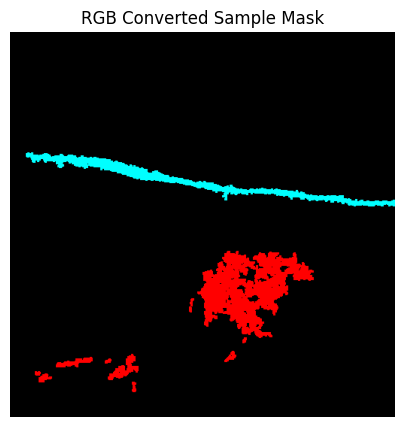

Number of connected regions for label : 1
Bounding box of first region: (160, 21, 232, 512)


In [69]:
# For testing, set the path to your label directory:
label_dir = "../labels_1D"  # Adjust this path as needed.
# Create the dataset object:
dataset = MaskOnlyDataset(label_dir)

# Get a sample mask from the dataset:
sample_mask = dataset[0]
print("Sample mask type:", type(sample_mask))
print("Sample mask shape:", sample_mask.shape)
print("Unique labels in sample mask:", torch.unique(sample_mask))
sample_mask_np = sample_mask.cpu().numpy()
sample_mask_rgb = translate_1d_to_rgb(sample_mask_np)
plt.figure(figsize=(5,5))
plt.imshow(sample_mask_rgb)
plt.title("RGB Converted Sample Mask")
plt.axis("off")
plt.show()
# Pick a label (e.g., label=1) and show how many regions are found:
regions_label1 = extract_connected_regions(sample_mask, 1)
print(f"Number of connected regions for label : {len(regions_label1)}")
if regions_label1:
    print("Bounding box of first region:", regions_label1[0]['bbox'])

translated_image_temp = random_translate_and_rotate_region(sample_mask, label_value=2, max_shift=10, debug=False)

    

test transformations

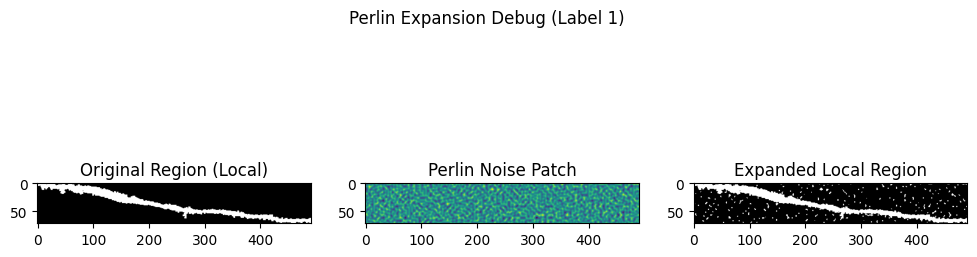

Perlin expanded region shape: (512, 512)


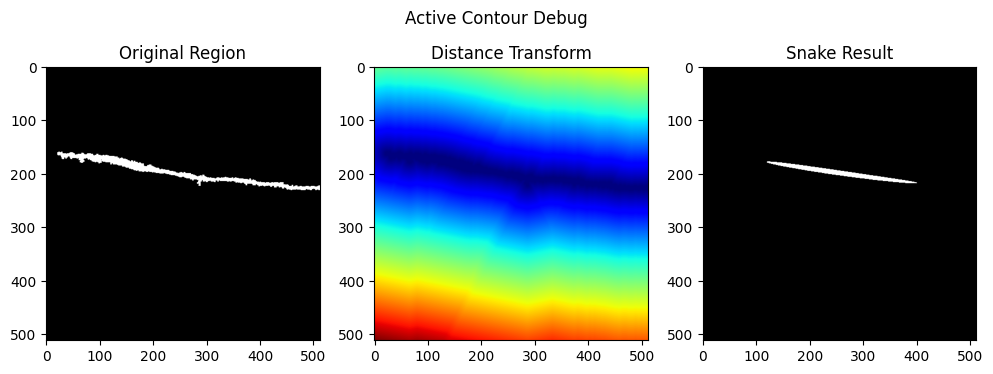

Snake deformed region shape: (512, 512)


In [70]:
j=0
if regions_label1:
    test_region = regions_label1[j]['binary_mask']
    expanded_region = perlin_expand_region(test_region, sample_mask, 1, noise_scale=5, threshold=0.75, debug=True)
    print("Perlin expanded region shape:", expanded_region.shape)
if regions_label1:
    test_region = regions_label1[j]['binary_mask']
    snake_region = active_contour_expand_region(test_region, alpha=0.15, beta=10.0, w_line=0, w_edge=0.5, debug=True)
    print("Snake deformed region shape:", snake_region.shape)


In [ ]:
def augment_mask_snake(mask_1d, alpha=0.015, beta=10.0, w_line=0.0, w_edge=1.0, debug=False):
    """
    Augments a mask using only the Snake deformation for labels 1-4.
    """
    mask_np = mask_1d.cpu().numpy().copy()
    H, W = mask_np.shape
    augmented_mask_np = np.zeros((H, W), dtype=np.int64)
    augmented_mask_np[mask_np == 0] = 0  # preserve background

    for label_value in [1, 2, 3, 4]:
        regions_info = extract_connected_regions(mask_1d, label_value)
        for region_dict in regions_info:
            region_mask_full = region_dict['binary_mask']
            final_region = active_contour_expand_region(region_mask_full, alpha=alpha, beta=beta,
                                                         w_line=w_line, w_edge=w_edge, debug=debug)
            overlap = (augmented_mask_np != 0) & (final_region == 1)
            final_region[overlap] = 0
            augmented_mask_np[final_region == 1] = label_value
    return torch.from_numpy(augmented_mask_np)

# Test the full augmentation on the sample mask (without debug plots):
snake_aug_mask = augment_mask_snake(sample_mask, alpha=0.15, beta=5.0, w_line=1.0, w_edge=1.0, debug=True)


In [ ]:
def augment_mask_perlin(mask_1d, noise_scale=20.0, threshold=0.5, debug=False):
    """
    Augments a mask using only the Perlin noise expansion for labels 1-4.
    """
    mask_np = mask_1d.cpu().numpy().copy()
    H, W = mask_np.shape
    augmented_mask_np = np.zeros((H, W), dtype=np.int64)
    augmented_mask_np[mask_np == 0] = 0  # preserve background

    for label_value in [1, 2, 3, 4]:
        regions_info = extract_connected_regions(mask_1d, label_value)
        for region_dict in regions_info:
            region_mask_full = region_dict['binary_mask']
            final_region = perlin_expand_region(region_mask_full, mask_1d, label_value,
                                                 noise_scale=noise_scale, threshold=threshold, debug=debug)
            overlap = (augmented_mask_np != 0) & (final_region == 1)
            final_region[overlap] = 0
            augmented_mask_np[final_region == 1] = label_value
    return torch.from_numpy(augmented_mask_np)
perlin_aug_mask = augment_mask_perlin(sample_mask, noise_scale=20
                                      , threshold=0.5, debug=True)
print("Perlin augmented mask shape:", perlin_aug_mask.shape)


Sample mask type: <class 'torch.Tensor'>
Sample mask shape: torch.Size([512, 512])
Unique labels in sample mask: tensor([0, 1, 2])


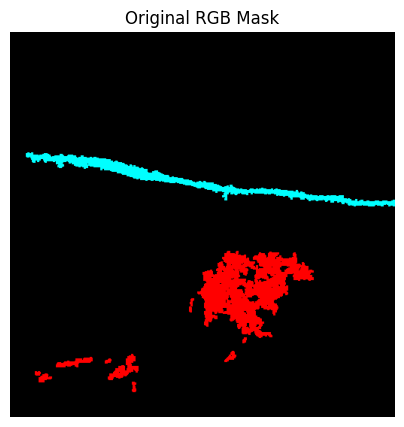

{1: [{'bbox': (160, 21, 232, 512), 'region_mask': array([[0, 0, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], shape=(72, 491), dtype=uint8), 'area': 4914, 'technique': 'None'}]}
{1: [{'bbox': (160, 21, 232, 512), 'region_mask': array([[0, 0, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], shape=(72, 491), dtype=uint8), 'area': 4914, 'technique': 'None'}], 2: [{'bbox': (291, 249, 407, 404), 'region_mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(116, 155), dtype=uint8), 'area': 9056, 'technique': 'None'}]}
{1: [{'bbox': (160, 21, 232, 5

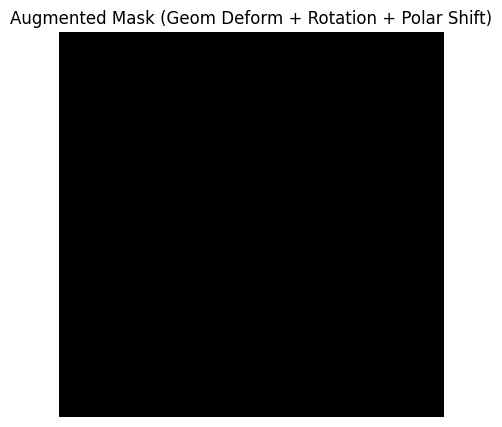

Technique log per label:
Label 1:
   None+Rot(0)+PolarShift => Attempts=1, Status=placed
Label 2:
   None+Rot(90)+PolarShift => Attempts=1, Status=placed
   None+Rot(180)+PolarShift => Attempts=1, Status=placed
   None+Rot(180)+PolarShift => Attempts=1, Status=placed
   None+Rot(270)+PolarShift => Attempts=1, Status=placed
   None+Rot(0)+PolarShift => Attempts=1, Status=placed
   None+Rot(90)+PolarShift => Attempts=1, Status=placed
   None+Rot(180)+PolarShift => Attempts=1, Status=placed
   None+Rot(270)+PolarShift => Attempts=1, Status=placed
   None+Rot(270)+PolarShift => Attempts=1, Status=placed
   None+Rot(270)+PolarShift => Attempts=1, Status=placed
Label 3:
Label 4:


In [4]:
# Cell 5: Example usage and visualization
# Cell 4: Combined augmentation function
from trans_mod2 import transform_and_place_regions_for_label,place_region_in_mask,transform_region
def augment_mask_with_snakes_and_perlin_debug(mask_1d,
                                              technique_choice="random",
                                              max_shift=30,
                                              debug=False,
                                              debug_save_dir=None):
    """
    For each label (1..4):
      1) Extract connected regions and apply morphological deformation 
         (perlin, snake, or none).
      2) Store them in new_regions[label].
    
    Then, for each label (1..4) in order:
      1) Sort the morphed regions by descending area (priority to bigger shapes).
      2) Rotate each region randomly (0, 90, 180, 270).
      3) Place it in the global mask with a random polar shift from the region's true centroid,
         allowing partial cropping if it goes out of bounds, and skipping if conflict arises.
    
    Returns:
      - augmented_mask_torch: the final augmented mask as a torch tensor, 
        with all labels placed (non-overlapping).
      - technique_log: dictionary summarizing each region's technique, attempts, status, etc.
    """
    import random
    import os
    
    if debug_save_dir is not None:
        os.makedirs(debug_save_dir, exist_ok=True)
    
    # Convert to numpy
    mask_np = mask_1d.cpu().numpy().copy()
    H, W = mask_np.shape
    
    # We'll keep a separate integer mask for each label in the final combination.
    #  0 => background
    #  1..4 => your classes
    augmented_mask_np = np.zeros((H, W), dtype=np.int64)
    
    # If there's a background, preserve it as 0
    augmented_mask_np[mask_np == 0] = 0
    
    # For logging
    technique_log = {1: [], 2: [], 3: [], 4: []}
    
    # 1) Build new_regions with morphological transformations
    new_regions = {}  # label -> list of dicts
    for lbl in [1, 2, 3, 4]:
        from copy import deepcopy
        regions_info = extract_connected_regions(mask_1d, lbl)
        new_regions[lbl] = []
        
        for region in regions_info:
            bbox = region['bbox']  # (r1, c1, r2, c2)
            r1, c1, r2, c2 = bbox
            
            # Crop the region from the full mask
            cropped_region = region['binary_mask'][r1:r2, c1:c2].copy()
            
            # Choose morphological deformation
            if technique_choice == "random":
                choice = random.choice(["perlin", "snake", "none"])
            else:
                choice = technique_choice
            
            if choice == "perlin":
                deformed_crop = perlin_expand_region(
                    cropped_region, mask_1d, lbl,
                    noise_scale=20, threshold=0.9, debug=False
                )
                morph_technique = "Perlin"
            elif choice == "snake":
                deformed_crop = active_contour_expand_region(
                    cropped_region, alpha=0.15, beta=10.0,
                    w_line=0.0, w_edge=1.0, debug=debug
                )
                morph_technique = "Snake"
            elif choice == "none":
                deformed_crop = cropped_region.copy()
                morph_technique = "None"
            else:
                deformed_crop = cropped_region.copy()
                morph_technique = "None"
            
            if debug:
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.imshow(cropped_region, cmap='gray')
                plt.title(f"Label {lbl} - Original Crop")
                plt.subplot(1, 2, 2)
                plt.imshow(deformed_crop, cmap='gray')
                plt.title(f"Label {lbl} - After {morph_technique}")
                plt.suptitle("Morphological Transformation")
                plt.show()
            
            indices = np.argwhere(deformed_crop == 1)
            area = indices.shape[0]
            new_regions[lbl].append({
                'bbox': bbox,
                'region_mask': deformed_crop,
                'area': area,
                'technique': morph_technique
            })
            print(new_regions)
    print(new_regions)
    # 2) Second loop: transform (rotate) + place (polar shift) for each label
    for lbl in [1, 2, 3, 4]:
        # Sort by descending area
        label_regions = sorted(new_regions[lbl], key=lambda r: r['area'], reverse=True)
        
        for region_data in label_regions:
            bbox = region_data['bbox']
            region_mask = region_data['region_mask']
            technique = region_data['technique']
            
            # (A) Rotate
            rotated_region, angle = transform_region(region_mask)
            
            # (B) Place using random polar shift from the region's centroid
            #     We'll temporarily place as "1" in a local mask, 
            #     then convert to "lbl" once no conflict.
            local_mask = np.zeros_like(augmented_mask_np, dtype=np.uint8)
            
            (placement, attempt_count) = place_region_in_mask(
                rotated_region, local_mask, bbox,
                max_shift=max_shift, placement_attempts=10
            )
            
            if placement is not None:
                # Merge local_mask into augmented_mask_np
                # Because local_mask has "1" where the region is placed, 
                # we map that to "lbl"
                augmented_mask_np[local_mask == 1] = lbl
                status = "placed"
            else:
                status = "skipped"
            
            # Log
            log_msg = f"{technique}+Rot({angle})+PolarShift => Attempts={attempt_count}, Status={status}"
            technique_log[lbl].append(log_msg)
            
            if debug:
                print(f"Label={lbl}, BBox={bbox}, {log_msg}")
                if placement is not None:
                    plt.figure(figsize=(10, 4))
                    plt.subplot(1, 2, 1)
                    plt.imshow(region_mask, cmap='gray')
                    plt.title("Morphed Crop")
                    plt.subplot(1, 2, 2)
                    plt.imshow(rotated_region, cmap='gray')
                    plt.title(f"Rotated {angle}°, Placed after {attempt_count} tries")
                    plt.show()
        
        # Optionally save intermediate mask for debugging
        if debug_save_dir is not None:
            save_path = os.path.join(debug_save_dir, f"label{lbl}_global_mask.png")
            cv2.imwrite(save_path, (augmented_mask_np * 50).astype(np.uint8))  # scaled for visualization
    
    # Convert final augmented mask back to torch
    augmented_mask_torch = torch.from_numpy(augmented_mask_np)
    return augmented_mask_torch, technique_log


# For testing, set the path to your label directory:
label_dir = "../labels_1D"  # Adjust as needed.
dataset = MaskOnlyDataset(label_dir)

# Load a sample mask from the dataset:
sample_mask = dataset[0]
print("Sample mask type:", type(sample_mask))
print("Sample mask shape:", sample_mask.shape)
print("Unique labels in sample mask:", torch.unique(sample_mask))

# Visualize the original mask (converted to RGB):
sample_mask_np = sample_mask.cpu().numpy()
sample_mask_rgb = translate_1d_to_rgb(sample_mask_np)
plt.figure(figsize=(5,5))
plt.imshow(sample_mask_rgb)
plt.title("Original RGB Mask")
plt.axis("off")
plt.show()

# Run the combined augmentation
augmented_mask, tech_log = augment_mask_with_snakes_and_perlin_debug(
    sample_mask,
    technique_choice="none",   # or "snake"/"perlin"/"random"
    max_shift=10,
    debug=False,
    debug_save_dir="./debug_augmented_regions"
)

# Visualize augmented mask (converted to RGB):
augmented_mask_np = augmented_mask.cpu().numpy()
augmented_mask_rgb = translate_1d_to_rgb(augmented_mask_np)
plt.figure(figsize=(5,5))
plt.imshow(augmented_mask_rgb)
plt.title("Augmented Mask (Geom Deform + Rotation + Polar Shift)")
plt.axis("off")
plt.show()

# Print the technique log:
print("Technique log per label:")
for lbl, log_entries in tech_log.items():
    print(f"Label {lbl}:")
    for entry in log_entries:
        print("  ", entry)



In [40]:
from trans_mod2 import flatten_and_augment_all_labels
def augment_mask_multiclass_singlepass(
    mask_1d,
    technique_choice="random",
    max_shift=30,
    debug=False
):
    """
    1) For each label 1..4, extract connected regions & morph (perlin/snake/none).
    2) Store them in new_regions[label].
    3) Flatten & place all labels in a single pass using flatten_and_augment_all_labels.
    4) Return final torch mask & technique_log.
    """
    mask_np = mask_1d.cpu().numpy()
    H, W = mask_np.shape

    # Step 1: Build new_regions
    new_regions = {1:[], 2:[], 3:[], 4:[]}
    for lbl in [1, 2, 3, 4]:
        # find connected regions for this label
        regions_info = extract_connected_regions(mask_1d, lbl)
        for region in regions_info:
            bbox = region['bbox']
            r1, c1, r2, c2 = bbox
            cropped_region = region['binary_mask'][r1:r2, c1:c2].copy()

            # morphological transform
            if technique_choice == "random":
                choice = random.choice(["perlin", "snake", "none"])
            else:
                choice = technique_choice

            if choice == "perlin":
                deformed_crop = perlin_expand_region(
                    cropped_region, mask_1d, lbl,
                    noise_scale=20, threshold=0.9, 
                    debug=False
                )
                morph_technique = "Perlin"
            elif choice == "snake":
                deformed_crop = active_contour_expand_region(
                    cropped_region, alpha=15, beta=10.0,
                    w_line=0.0, w_edge=1.0, debug=debug
                )
                morph_technique = "Snake"
            elif choice == "none":
                deformed_crop = cropped_region.copy()
                morph_technique = "None"
            else:
                deformed_crop = cropped_region.copy()
                morph_technique = "None"

            # Debug: show the morphological step
            if debug:
                plt.figure(figsize=(8,3))
                plt.subplot(1,2,1)
                plt.imshow(cropped_region, cmap='gray')
                plt.title(f"Label {lbl} Original Crop")
                plt.subplot(1,2,2)
                plt.imshow(deformed_crop, cmap='gray')
                plt.title(f"Label {lbl} After {morph_technique}")
                plt.show()

            area = np.count_nonzero(deformed_crop)
            new_regions[lbl].append({
                "bbox": bbox,
                "region_mask": deformed_crop,
                "area": area,
                "technique": morph_technique
            })

    # Step 2/3: Flatten & place in one pass
    augmented_mask_np, technique_log = flatten_and_augment_all_labels(
        new_regions, H, W, 
        max_shift=max_shift, 
        placement_attempts=10, 
        debug=debug
    )

    # Convert to torch
    augmented_mask_torch = torch.from_numpy(augmented_mask_np)
    return augmented_mask_torch, technique_log


Sample mask type: <class 'torch.Tensor'>
Sample mask shape: torch.Size([512, 512])
Unique labels in sample mask: tensor([0, 1, 2])


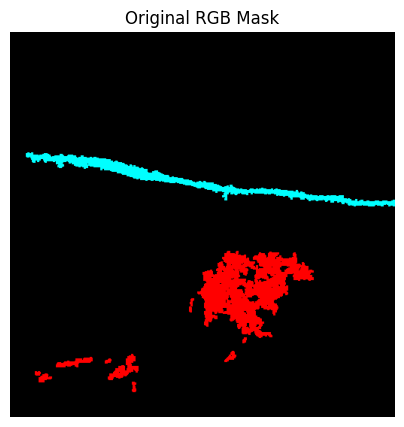

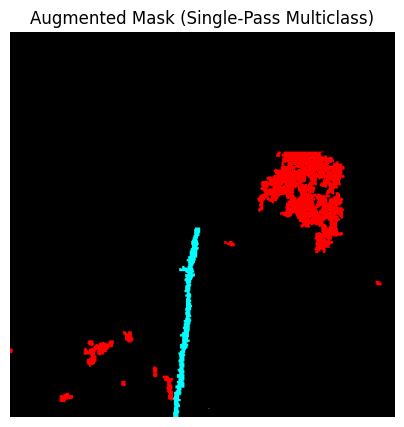

Technique log per label:
Label 1:
   Perlin+Rot(270) => Attempts=3, Status=placed
Label 2:
   Perlin+Rot(270) => Attempts=1, Status=placed
   Perlin+Rot(180) => Attempts=1, Status=placed
   Perlin+Rot(90) => Attempts=1, Status=placed
   Perlin+Rot(270) => Attempts=1, Status=placed
   Perlin+Rot(0) => Attempts=1, Status=placed
   Perlin+Rot(270) => Attempts=2, Status=placed
   Perlin+Rot(0) => Attempts=2, Status=placed
   Perlin+Rot(0) => Attempts=2, Status=placed
   Perlin+Rot(270) => Attempts=2, Status=placed
   Perlin+Rot(270) => Attempts=1, Status=placed
Label 3:
Label 4:


In [90]:
# Assume you have already imported everything you need (MaskOnlyDataset, etc.)
# and that 'augment_mask_multiclass_singlepass' and 'translate_1d_to_rgb'
# are defined in your notebook or imported from your module.

# 1) Load a sample mask from the dataset:
label_dir = "../labels_1D"  # Adjust as needed
dataset = MaskOnlyDataset(label_dir)

sample_mask = dataset[0]
print("Sample mask type:", type(sample_mask))
print("Sample mask shape:", sample_mask.shape)
print("Unique labels in sample mask:", torch.unique(sample_mask))

# 2) Visualize the original mask in RGB:
sample_mask_np = sample_mask.cpu().numpy()
sample_mask_rgb = translate_1d_to_rgb(sample_mask_np)
plt.figure(figsize=(5,5))
plt.imshow(sample_mask_rgb)
plt.title("Original RGB Mask")
plt.axis("off")
plt.show()

# 3) Run the new single-pass augmentation:
augmented_mask, tech_log = augment_mask_multiclass_singlepass(
    sample_mask,
    technique_choice="perlin",  # or "snake"/"perlin"/"random"
    max_shift=300,
    debug=False  # set to False if you don't want intermediate debug plots
)

# 4) Visualize the augmented result:
augmented_mask_np = augmented_mask.cpu().numpy()
augmented_mask_rgb = translate_1d_to_rgb(augmented_mask_np)
plt.figure(figsize=(5,5))
plt.imshow(augmented_mask_rgb)
plt.title("Augmented Mask (Single-Pass Multiclass)")
plt.axis("off")
plt.show()

# 5) Print the technique log:
print("Technique log per label:")
for lbl, log_entries in tech_log.items():
    print(f"Label {lbl}:")
    for entry in log_entries:
        print("  ", entry)


In [83]:
import opensimplex
def generate_opensimplex_noise_2d(height, width, scale=20.0,
                                  seed=0,
                                  octaves=1,
                                  lacunarity=2.0,
                                  persistence=0.5):
    """
    Generates a 2D OpenSimplex noise array of shape (height, width),
    normalized to [0,1].

    Parameters:
      - scale: controls the overall frequency. Larger scale => coarser features.
      - seed: random seed for opensimplex.
      - octaves: how many layers of noise to sum.
      - lacunarity: frequency multiplier per octave.
      - persistence: amplitude multiplier per octave.

    Returns: np.array of shape (height, width) with values in [0..1].
    """
    # Initialize OpenSimplex with a given seed
    opensimplex.seed(seed)

    noise_array = np.zeros((height, width), dtype=np.float32)

    # If you want multi-octave noise, we sum multiple calls with different frequencies.
    for y in range(height):
        for x in range(width):
            # For multi-octave fractal noise:
            freq = 1.0
            amp = 1.0
            total_val = 0.0
            total_amp = 0.0

            for _ in range(octaves):
                # opensimplex.noise2(xCoord, yCoord) => returns [-1..1]
                val = opensimplex.noise2(x * freq / scale, y * freq / scale)
                total_val += val * amp
                total_amp += amp

                freq *= lacunarity
                amp *= persistence

            # Average across octaves
            final_val = total_val / total_amp  # still ~ [-1..1]
            # shift/scale to [0..1]
            final_val = 0.5 * (final_val + 1.0)
            noise_array[y, x] = final_val

    return noise_array

def opensimplex_expand_region(region_mask_full,
                              mask_1d,
                              label_value,
                              scale=20.0,
                              threshold=0.5,
                              octaves=1,
                              lacunarity=2.0,
                              persistence=0.5,
                              debug=False):
    """
    Applies OpenSimplex noise expansion on a connected region.

    1) Locates bounding box of the region in 'region_mask_full'.
    2) Generates a noise patch (height=region_h, width=region_w).
    3) Thresholds it to create an expansion mask.
    4) Merges with the original region, but only where the background is 0
       (i.e., we do NOT expand into other labels).

    Returns an updated version of 'region_mask_full' with expansions.
    """

    H, W = region_mask_full.shape
    coords = np.argwhere(region_mask_full == 1)
    if coords.size == 0:
        return region_mask_full  # no pixels => nothing to expand

    # bounding box
    r1, c1 = coords.min(axis=0)
    r2, c2 = coords.max(axis=0)
    region_h = r2 - r1 + 1
    region_w = c2 - c1 + 1

    # 1) Generate noise patch
    noise_patch = generate_opensimplex_noise_2d(
        height=region_h,
        width=region_w,
        scale=scale,
        seed=0,        # or random seed if you like
        octaves=octaves,
        lacunarity=lacunarity,
        persistence=persistence
    )

    # 2) Threshold => expansion attempt
    expansion_mask_local = (noise_patch > threshold).astype(np.uint8)

    # 3) Combine with original region
    region_local = region_mask_full[r1:r2+1, c1:c2+1]
    # OR them => attempt to expand
    expanded_local = np.logical_or(region_local, expansion_mask_local).astype(np.uint8)

    # 4) Disallow expansion into other labels
    #    i.e., only expand into background=0 in 'mask_1d'.
    mask_local = mask_1d[r1:r2+1, c1:c2+1].cpu().numpy()
    for rr in range(region_h):
        for cc in range(region_w):
            if expanded_local[rr, cc] == 1 and region_local[rr, cc] == 0:
                # if it's background in region_mask_full but not background in mask_1d => revert
                if mask_local[rr, cc] != 0:
                    expanded_local[rr, cc] = 0

    # 5) Debug visualization
    if debug:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(region_local, cmap='gray')
        plt.title("Original Region (Local)")
        plt.subplot(1, 3, 2)
        plt.imshow(noise_patch, cmap='viridis')
        plt.title("OpenSimplex Noise Patch")
        plt.subplot(1, 3, 3)
        plt.imshow(expanded_local, cmap='gray')
        plt.title("Expanded Local Region")
        plt.show()

    # 6) Update region_mask_full with expanded_local
    updated_region_mask_full = region_mask_full.copy()
    updated_region_mask_full[r1:r2+1, c1:c2+1] = expanded_local
    return updated_region_mask_full

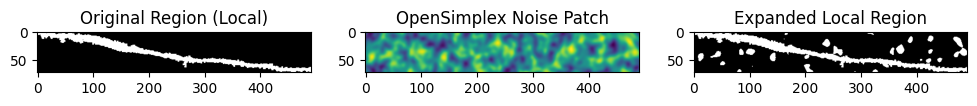

Perlin expanded region shape: (512, 512)


In [82]:
j=0
if regions_label1:
    test_region = regions_label1[j]['binary_mask']
    expanded_region = opensimplex_expand_region(test_region, sample_mask, 1, threshold=0.7,octaves=2, debug=True)
    print("Perlin expanded region shape:", expanded_region.shape)
